In [1]:
# pip install surya-ocr
import torch
print(torch.cuda.is_available())

True


In [2]:
import os 
os.environ["RECOGNITION_BATCH_SIZE"] = "512"
os.environ["DETECTOR_BATCH_SIZE"] = "36"
os.environ["ORDER_BATCH_SIZE"] = "32"
os.environ["RECOGNITION_STATIC_CACHE"] = "true"

In [3]:
from PIL import Image


from pdf2image import convert_from_path, convert_from_bytes

# Convert PDF to images
images = convert_from_path(
    "/home/duckq1u/Documents/obsidian_aio/Notebook/Môn học trên trường/OCR thầy minh/OCR/Attachments/PDF_form_list/4216620650.pdf"
)

In [4]:
from surya.recognition import RecognitionPredictor
from surya.detection import DetectionPredictor
from surya.layout import LayoutPredictor
from PIL import ImageDraw

def draw_bounding_boxes(image, predictions,is_layout=False):
    draw = ImageDraw.Draw(image)
    # Rounded rectangle parameters
    border_radius = 0  # Corner radius
    outline_color = "red"  # Box color
    outline_width = 1  # Box thickness
    
    if is_layout:
        predictions = predictions[0].bboxes
    else:
        predictions = predictions[0].text_lines
        
    paragraph = ""
    
    # Loop through each set of coordinates
    for coords in predictions:
        # Extract x and y values
        x_values = [x for x, y in coords.polygon]
        y_values = [y for x, y in coords.polygon]

        # Calculate bounding box
        min_x = min(x_values)
        max_x = max(x_values)
        min_y = min(y_values)
        max_y = max(y_values)

        # Draw the rounded rectangle
        draw.rounded_rectangle(
            [(min_x, min_y), (max_x, max_y)],
            radius=border_radius,
            outline=outline_color,
            width=outline_width,
        )
        paragraph += coords.text + "\n"
    return image, paragraph


def rounding_box(image, is_layout=False):
    image_cp = image.copy()
    if is_layout: 
        layout_predictor = LayoutPredictor()
        predictions = layout_predictor([image_cp])  
    else: 
        langs = ["en"]  # Replace with your languages or pass None (recommended to use None)
        recognition_predictor = RecognitionPredictor()
        detection_predictor = DetectionPredictor()

        predictions = recognition_predictor([image_cp], [langs], detection_predictor)
    
    image_output, paragraph =  draw_bounding_boxes(image_cp, predictions, is_layout)
    return image_output, paragraph


/home/duckq1u/miniconda3/envs/OCR/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


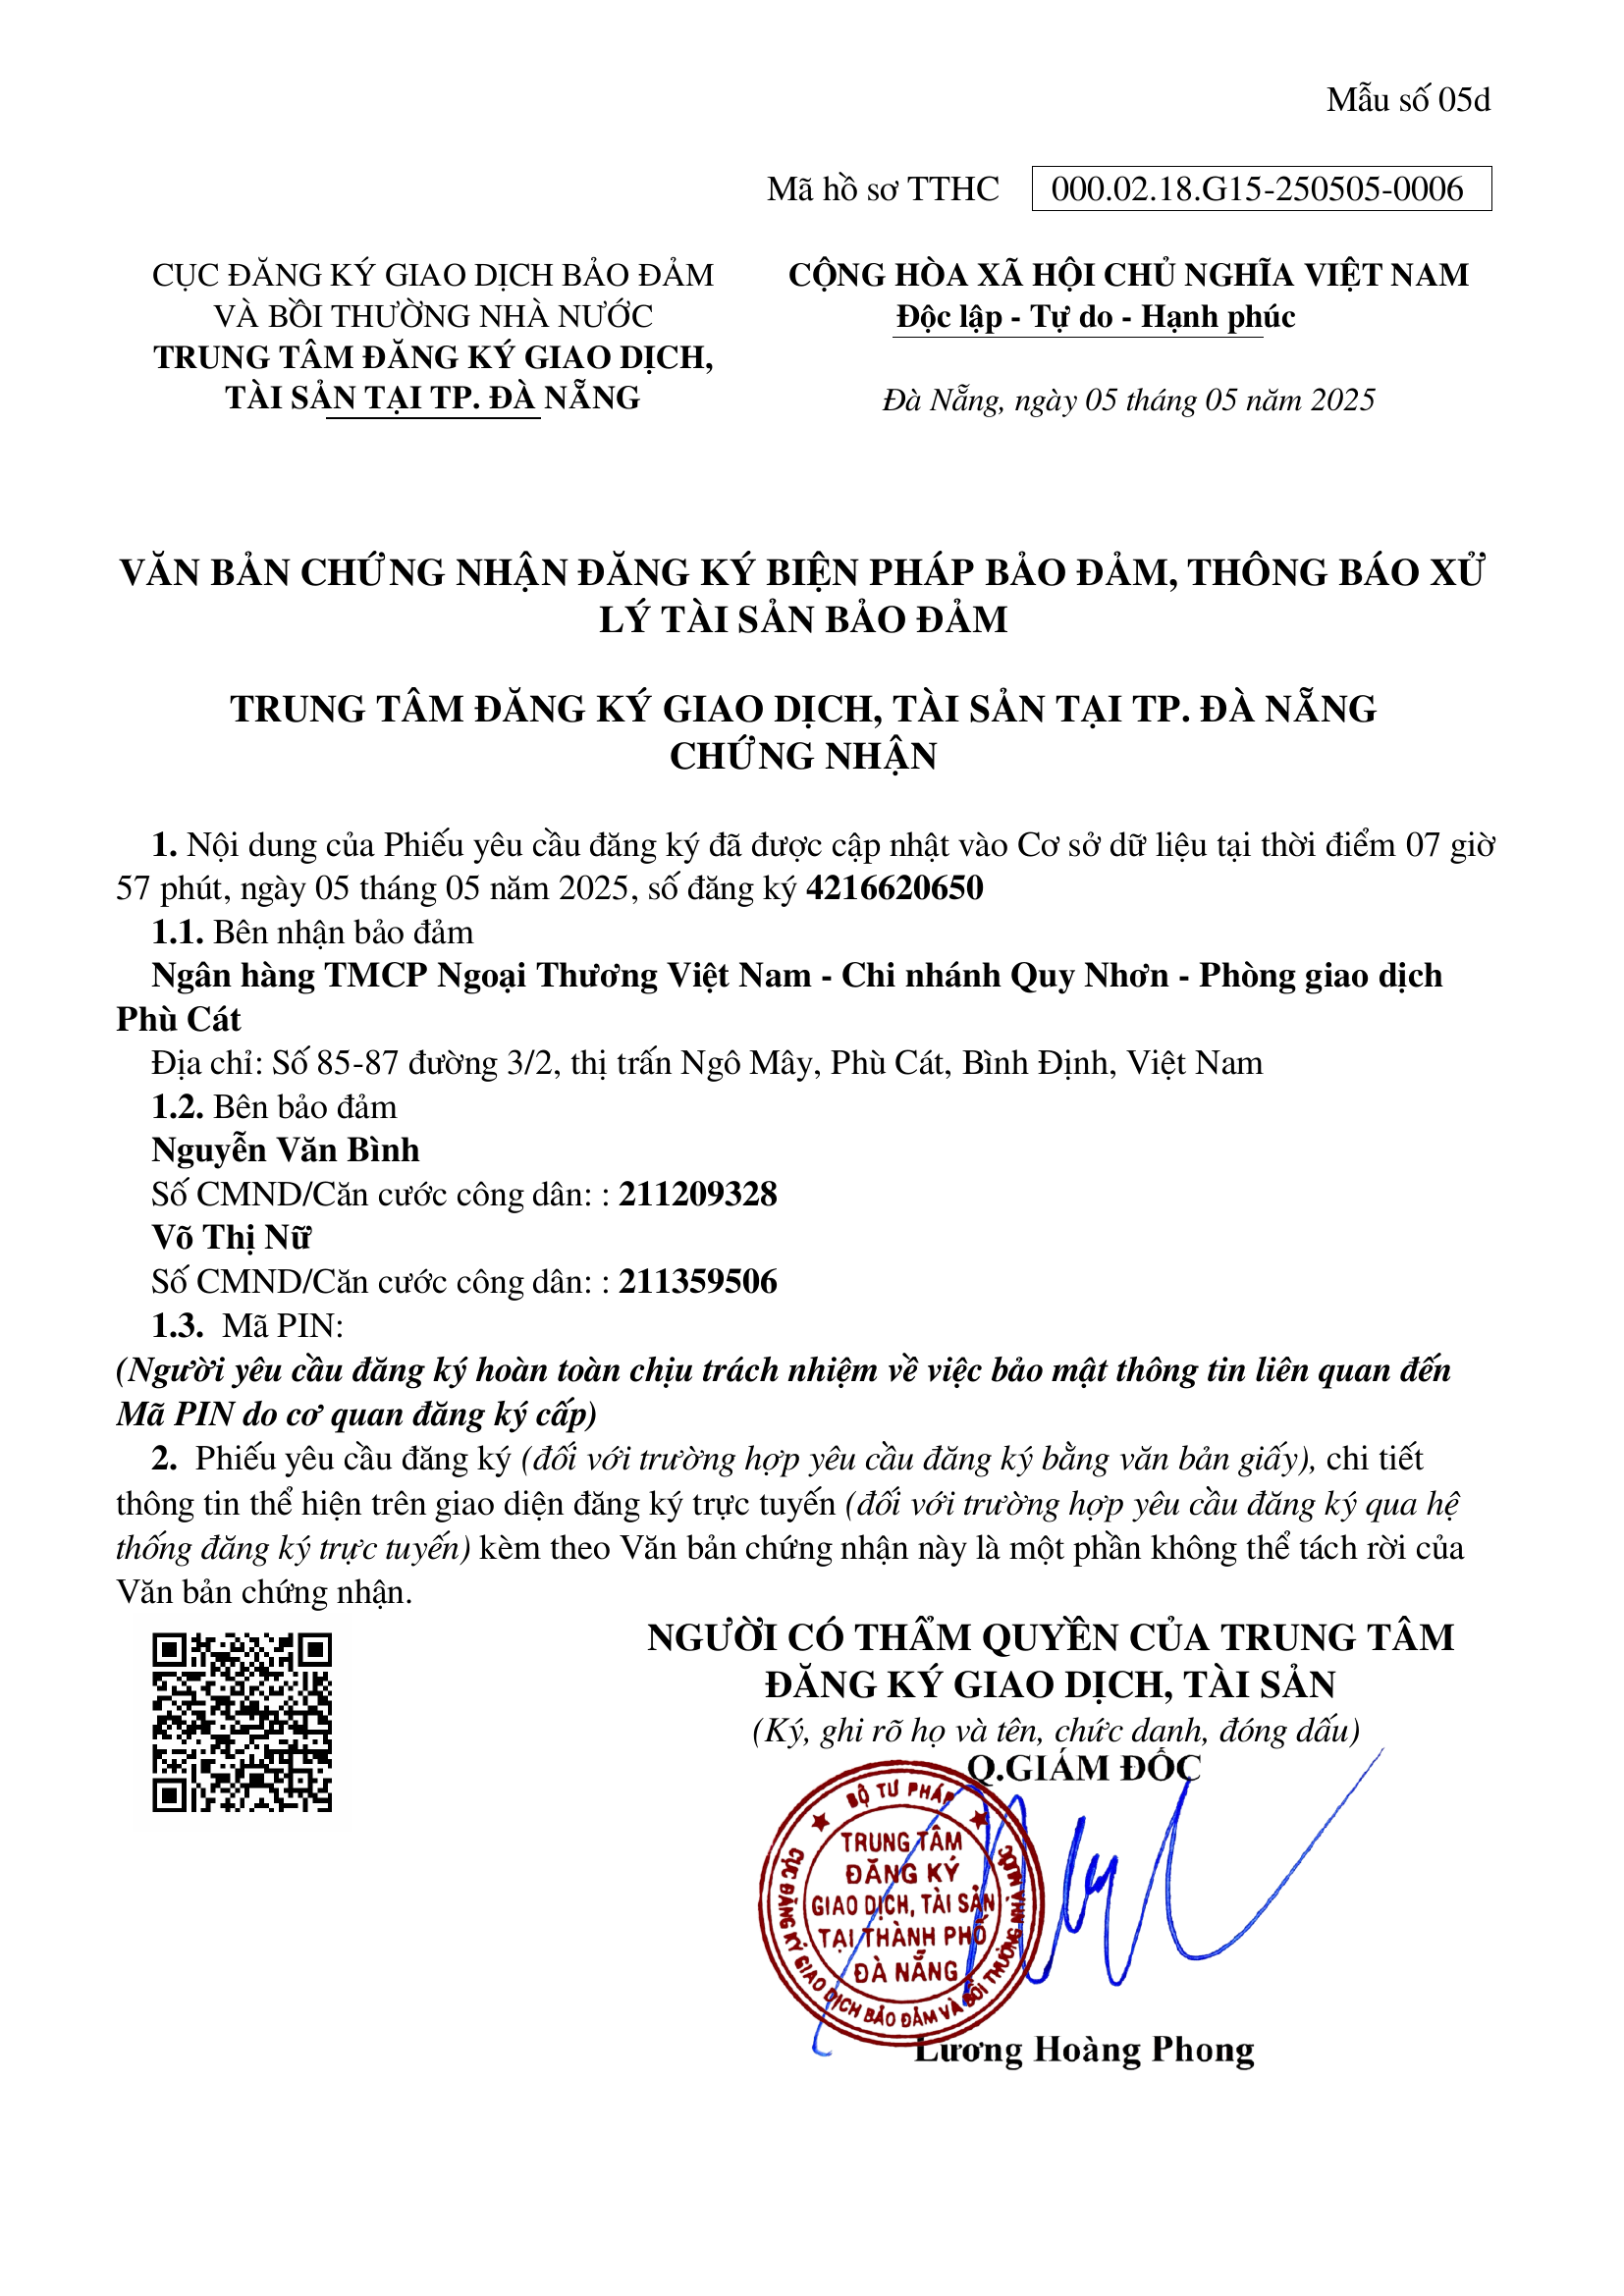

In [6]:
images[0]

In [8]:
image, paragraph = rounding_box(images, is_layout=False)


TypeError: unhashable type: 'list'

In [ ]:
import torch
torch.cuda.empty_cache() 

In [ ]:
import numpy as np
import torch
import torchvision.transforms as T
# from decord import VideoReader, cpu
from PIL import Image
from torchvision.transforms.functional import InterpolationMode
from transformers import AutoModel, AutoTokenizer

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def build_transform(input_size):
    MEAN, STD = IMAGENET_MEAN, IMAGENET_STD
    transform = T.Compose([
        T.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img),
        T.Resize((input_size, input_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=MEAN, std=STD)
    ])
    return transform

def find_closest_aspect_ratio(aspect_ratio, target_ratios, width, height, image_size):
    best_ratio_diff = float('inf')
    best_ratio = (1, 1)
    area = width * height
    for ratio in target_ratios:
        target_aspect_ratio = ratio[0] / ratio[1]
        ratio_diff = abs(aspect_ratio - target_aspect_ratio)
        if ratio_diff < best_ratio_diff:
            best_ratio_diff = ratio_diff
            best_ratio = ratio
        elif ratio_diff == best_ratio_diff:
            if area > 0.5 * image_size * image_size * ratio[0] * ratio[1]:
                best_ratio = ratio
    return best_ratio

def dynamic_preprocess(image, min_num=1, max_num=12, image_size=448, use_thumbnail=False):
    orig_width, orig_height = image.size
    aspect_ratio = orig_width / orig_height

    # calculate the existing image aspect ratio
    target_ratios = set(
        (i, j) for n in range(min_num, max_num + 1) for i in range(1, n + 1) for j in range(1, n + 1) if
        i * j <= max_num and i * j >= min_num)
    target_ratios = sorted(target_ratios, key=lambda x: x[0] * x[1])

    # find the closest aspect ratio to the target
    target_aspect_ratio = find_closest_aspect_ratio(
        aspect_ratio, target_ratios, orig_width, orig_height, image_size)

    # calculate the target width and height
    target_width = image_size * target_aspect_ratio[0]
    target_height = image_size * target_aspect_ratio[1]
    blocks = target_aspect_ratio[0] * target_aspect_ratio[1]

    # resize the image
    resized_img = image.resize((target_width, target_height))
    processed_images = []
    for i in range(blocks):
        box = ( 
            (i % (target_width // image_size)) * image_size,
            (i // (target_width // image_size)) * image_size,
            ((i % (target_width // image_size)) + 1) * image_size,
            ((i // (target_width // image_size)) + 1) * image_size
        )
        # split the image
        split_img = resized_img.crop(box)
        processed_images.append(split_img)
    assert len(processed_images) == blocks
    if use_thumbnail and len(processed_images) != 1:
        thumbnail_img = image.resize((image_size, image_size))
        processed_images.append(thumbnail_img)
    return processed_images

def load_image(image_file, input_size=448, max_num=12):
    image = image_file.convert('RGB')
    transform = build_transform(input_size=input_size)
    images = dynamic_preprocess(image, image_size=input_size, use_thumbnail=True, max_num=max_num)
    pixel_values = [transform(image) for image in images]
    pixel_values = torch.stack(pixel_values)
    return pixel_values

model = AutoModel.from_pretrained(
    "5CD-AI/Vintern-1B-v3_5",
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
    use_flash_attn=False,
).eval().cuda()

tokenizer = AutoTokenizer.from_pretrained("5CD-AI/Vintern-1B-v3_5", trust_remote_code=True, use_fast=False)


FlashAttention2 is not installed.


## Interface model

In [ ]:
# Preprocess an image before passing to the model
pixel_values = load_image(image, max_num=12).to(torch.bfloat16).cuda()

# Generate text from the image
generation_config = dict(max_new_tokens= 2042, do_sample=False, num_beams = 3, repetition_penalty=2.5)
think_prompt_format = f"<image>\nTrích xuất thông tin về: chi tiết thông tin đăng ký, xóa đơn đăng ký, mô tả về bên bảo đảm, bên nhận bảo đảm."
response, history = model.chat(tokenizer, pixel_values, think_prompt_format, generation_config, history=None, return_history=True)
print(f'{response}')

In [ ]:
print(think_prompt_format)